In [3]:
# ============================================
# SECTION 1: SETUP & DATA LOADING
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("=" * 70)
print("EXPLORATORY DATA ANALYSIS")
print("Smart Criminal Judgment Analysis System")
print("=" * 70)

print()

# Load cleaned dataset
df = pd.read_csv('dataset_cleaned_final.csv')

print(f" Loaded dataset: {len(df)} records, {len(df.columns)} features")
print()


EXPLORATORY DATA ANALYSIS
Smart Criminal Judgment Analysis System

 Loaded dataset: 1251 records, 97 features



In [5]:
print("=" * 70)
print("SECTION 2: DATASET OVERVIEW")
print("=" * 70)
print()

# Basic info
print(" DATASET SHAPE")
print(f"Records: {len(df):,}")
print(f"Features: {len(df.columns)}")
print()

# Memory usage
print(f" Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print()

# Missing data summary
print(" MISSING DATA SUMMARY")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing_Count': missing[missing > 0],
    'Percentage': missing_pct[missing > 0]
}).sort_values('Percentage', ascending=False)

if len(missing_df) > 0:
    print(missing_df.head(15))
else:
    print(" No missing values in critical fields!")
print()

# Data types
print(" DATA TYPES DISTRIBUTION")
print(df.dtypes.value_counts())
print()

SECTION 2: DATASET OVERVIEW

 DATASET SHAPE
Records: 1,251
Features: 97

 Memory Usage: 11.93 MB

 MISSING DATA SUMMARY
                                Missing_Count  Percentage
reserved_for_future_use                  1251      100.00
dying_declaration_reliability            1179       94.24
language_of_criminal                     1007       80.50
hc_compensation_amount                   1001       80.02
final_charge_after_appeal                1001       80.02
coa_compensation_amount                   968       77.38
cause_of_death_exact_text                 945       75.54
num_defence_witnesses                     923       73.78
num_prosecution_witnesses                 907       72.50
sentencing_principles_applied             905       72.34
weapon_type                               891       71.22
procedural_defects_description            862       68.90
hc_fine_amount                            774       61.87
coa_fine_amount                           736       58.83
legal_erro

In [7]:
print("=" * 70)
print("SECTION 3: TARGET VARIABLE ANALYSIS")
print("=" * 70)
print()

# Primary target: Appeal Outcome
print(" PRIMARY TARGET: Appeal Outcome (outcome_clean)")
print("-" * 70)
outcome_counts = df['outcome_clean'].value_counts()
outcome_pct = (outcome_counts / len(df) * 100).round(2)

outcome_summary = pd.DataFrame({
    'Count': outcome_counts,
    'Percentage': outcome_pct
})
print(outcome_summary)
print()

# Class balance assessment
max_pct = outcome_pct.max()
min_pct = outcome_pct.min()
imbalance_ratio = max_pct / min_pct

print(f"Class Balance Assessment:")
print(f"  Imbalance Ratio: {imbalance_ratio:.2f}:1")
if imbalance_ratio < 3:
    print(f"   Well balanced (ratio < 3:1)")
elif imbalance_ratio < 5:
    print(f"  ⚠️  Moderately imbalanced (3:1 to 5:1)")
else:
    print(f"  ❌ Highly imbalanced (ratio > 5:1)")
print()

# Secondary target: Conviction Status
print(" SECONDARY TARGET: Conviction Status (conviction_clean)")
print("-" * 70)
conviction_counts = df['conviction_clean'].value_counts()
conviction_pct = (conviction_counts / len(df) * 100).round(2)

conviction_summary = pd.DataFrame({
    'Count': conviction_counts,
    'Percentage': conviction_pct
})
print(conviction_summary)
print()

# Combined target
print(" COMBINED TARGET: Combined Outcome")
print("-" * 70)
combined_counts = df['combined_outcome'].value_counts()
combined_pct = (combined_counts / len(df) * 100).round(2)

combined_summary = pd.DataFrame({
    'Count': combined_counts,
    'Percentage': combined_pct
})
print(combined_summary)
print()

# Cross-tabulation
print(" CROSS-TABULATION: Outcome vs Conviction")
print("-" * 70)
cross_tab = pd.crosstab(
    df['outcome_clean'],
    df['conviction_clean'],
    margins=True
)
print(cross_tab)
print()

# Percentage cross-tab
print(" PERCENTAGE BREAKDOWN (Row-wise)")
print("-" * 70)
cross_pct = pd.crosstab(
    df['outcome_clean'],
    df['conviction_clean'],
    normalize='index'
) * 100
print(cross_pct.round(1))
print()

SECTION 3: TARGET VARIABLE ANALYSIS

 PRIMARY TARGET: Appeal Outcome (outcome_clean)
----------------------------------------------------------------------
                  Count  Percentage
outcome_clean                      
Appeal_Dismissed    588       47.00
Appeal_Allowed      505       40.37
Partly_Allowed      158       12.63

Class Balance Assessment:
  Imbalance Ratio: 3.72:1
  ⚠️  Moderately imbalanced (3:1 to 5:1)

 SECONDARY TARGET: Conviction Status (conviction_clean)
----------------------------------------------------------------------
                  Count  Percentage
conviction_clean                   
Convicted           649       51.88
Acquitted           394       31.49
Modified            148       11.83
Remanded             60        4.80

 COMBINED TARGET: Combined Outcome
----------------------------------------------------------------------
                           Count  Percentage
combined_outcome                            
Dismissed_Convicted          

In [8]:
print("=" * 70)
print("SECTION 4: FEATURE DISTRIBUTION ANALYSIS")
print("=" * 70)
print()

# Offense Categories
print("  OFFENSE CATEGORIES (Top 20)")
print("-" * 70)
offense_counts = df['offence_category'].value_counts().head(20)
offense_pct = (offense_counts / len(df) * 100).round(2)

offense_summary = pd.DataFrame({
    'Count': offense_counts,
    'Percentage': offense_pct
})
print(offense_summary)
print()

# Appeal Type
if 'appeal_type' in df.columns:
    print("📋 APPEAL TYPE DISTRIBUTION")
    print("-" * 70)
    appeal_type_counts = df['appeal_type'].value_counts()
    appeal_type_pct = (appeal_type_counts / len(df) * 100).round(2)
    
    appeal_summary = pd.DataFrame({
        'Count': appeal_type_counts,
        'Percentage': appeal_type_pct
    })
    print(appeal_summary)
    print()

# Evidence Presence
print("🔍 EVIDENCE TYPE PRESENCE")
print("-" * 70)
evidence_fields = [
    'eyewitness_present',
    'expert_evidence_present',
    'forensic_evidence_present',
    'dying_declaration_present',
    'confession_present'
]

for field in evidence_fields:
    if field in df.columns:
        yes_count = (df[field] == 'Yes').sum()
        yes_pct = (yes_count / len(df) * 100).round(2)
        print(f"{field:35s}: {yes_count:4d} ({yes_pct:5.1f}%)")
print()

# Medical Evidence Strength
if 'medical_evidence_strength' in df.columns:
    print(" MEDICAL EVIDENCE STRENGTH")
    print("-" * 70)
    med_counts = df['medical_evidence_strength'].value_counts()
    med_pct = (med_counts / len(df) * 100).round(2)
    
    med_summary = pd.DataFrame({
        'Count': med_counts,
        'Percentage': med_pct
    })
    print(med_summary)
    print()

# Chain of Custody Quality
if 'chain_of_custody_quality' in df.columns:
    print("🔗 CHAIN OF CUSTODY QUALITY")
    print("-" * 70)
    custody_counts = df['chain_of_custody_quality'].value_counts()
    custody_pct = (custody_counts / len(df) * 100).round(2)
    
    custody_summary = pd.DataFrame({
        'Count': custody_counts,
        'Percentage': custody_pct
    })
    print(custody_summary)
    print()


SECTION 4: FEATURE DISTRIBUTION ANALYSIS

  OFFENSE CATEGORIES (Top 20)
----------------------------------------------------------------------
                                           Count  Percentage
offence_category                                            
Murder                                       329       26.30
Drug Trafficking                             157       12.55
Rape                                          65        5.20
Grave Sexual Abuse                            60        4.80
Bribery                                       35        2.80
Other                                         23        1.84
Forest Offence                                19        1.52
Trafficking and possession of heroin          18        1.44
Drug Possession                               15        1.20
Robbery                                       15        1.20
Murder and Robbery                            14        1.12
Attempted Murder                              13        1.04
Gra

In [9]:
print("=" * 70)
print("SECTION 5: TEXT DATA ANALYSIS")
print("=" * 70)
print()

# Text length analysis
text_fields = [
    'brief_facts_summary',
    'grounds_of_appeal_raw_text_summary',
    'court_of_appeal_analysis_summary'
]

print(" TEXT LENGTH STATISTICS")
print("-" * 70)
print(f"{'Field':<45s} {'Mean':>8s} {'Median':>8s} {'Min':>6s} {'Max':>6s}")
print("-" * 70)

for field in text_fields:
    if field in df.columns:
        lengths = df[field].dropna().astype(str).str.len()
        print(f"{field:<45s} {lengths.mean():>8.0f} {lengths.median():>8.0f} {lengths.min():>6.0f} {lengths.max():>6.0f}")
print()


SECTION 5: TEXT DATA ANALYSIS

 TEXT LENGTH STATISTICS
----------------------------------------------------------------------
Field                                             Mean   Median    Min    Max
----------------------------------------------------------------------
brief_facts_summary                                472      437     66   1199
grounds_of_appeal_raw_text_summary                 373      322     25   1069
court_of_appeal_analysis_summary                   659      595    183   1634



In [10]:
print("=" * 70)
print("SECTION 6: GROUNDS OF APPEAL ANALYSIS")
print("=" * 70)
print()

# Get all ground columns
ground_cols = [col for col in df.columns if col.startswith('gnd_')]

print("📋 GROUNDS RAISED (Frequency)")
print("-" * 70)

ground_stats = []
for col in ground_cols:
    if col != 'gnd_other_description':
        yes_count = (df[col] == 'Yes').sum()
        yes_pct = (yes_count / len(df) * 100).round(2)
        ground_stats.append({
            'Ground': col.replace('gnd_', '').replace('_', ' ').title(),
            'Count': yes_count,
            'Percentage': yes_pct
        })

ground_df = pd.DataFrame(ground_stats).sort_values('Count', ascending=False)
print(ground_df.to_string(index=False))
print()

# Total grounds raised
if 'total_grounds_raised' in df.columns:
    print("📊 TOTAL GROUNDS RAISED PER CASE")
    print("-" * 70)
    grounds_dist = df['total_grounds_raised'].value_counts().sort_index()
    print(grounds_dist)
    print()
    print(f"Average grounds per case: {df['total_grounds_raised'].mean():.2f}")
    print(f"Median grounds per case: {df['total_grounds_raised'].median():.0f}")
    print()

# ============================================
# SECTION 7: TEMPORAL ANALYSIS
# ============================================



SECTION 6: GROUNDS OF APPEAL ANALYSIS

📋 GROUNDS RAISED (Frequency)
----------------------------------------------------------------------
                          Ground  Count  Percentage
Sentence Excessive Or Inadequate    739       59.07
                  Contradictions    646       51.64
             Misdirection On Law    588       47.00
                           Other    533       42.61
                Procedural Error    512       40.93
   Judicial Bias Or Unfair Trial    230       18.39
     Circumstantial Insufficient    214       17.11
            Wrong Identification    187       14.95
           Medical Inconsistency    159       12.71
                Chain Of Custody    123        9.83
                 Delay Prejudice    108        8.63
      Dying Declaration Validity     64        5.12
          Illegal Search Or Raid     28        2.24
                    New Evidence      4        0.32

📊 TOTAL GROUNDS RAISED PER CASE
------------------------------------------------

In [11]:
print("=" * 70)
print("SECTION 7: TEMPORAL ANALYSIS")
print("=" * 70)
print()

# Cases by year
if 'coa_year' in df.columns:
    print("📅 CASES BY YEAR")
    print("-" * 70)
    year_counts = df['coa_year'].value_counts().sort_index()
    print(year_counts)
    print()
    
    # Outcome trends by year
    print("📊 OUTCOME TRENDS BY YEAR")
    print("-" * 70)
    year_outcome = pd.crosstab(
        df['coa_year'],
        df['outcome_clean'],
        normalize='index'
    ) * 100
    print(year_outcome.round(1))

    
    print()

# Appeal duration analysis
if 'appeal_duration_days' in df.columns:
    print("⏱️  APPEAL DURATION STATISTICS")
    print("-" * 70)
    duration = df['appeal_duration_days'].dropna()
    print(f"Mean duration: {duration.mean():.0f} days ({duration.mean()/365:.1f} years)")
    print(f"Median duration: {duration.median():.0f} days ({duration.median()/365:.1f} years)")
    print(f"Min duration: {duration.min():.0f} days")
    print(f"Max duration: {duration.max():.0f} days ({duration.max()/365:.1f} years)")
    print()


SECTION 7: TEMPORAL ANALYSIS

📅 CASES BY YEAR
----------------------------------------------------------------------
coa_year
2004.0      1
2021.0    160
2022.0    272
2023.0    254
2024.0    351
2025.0    212
Name: count, dtype: int64

📊 OUTCOME TRENDS BY YEAR
----------------------------------------------------------------------
outcome_clean  Appeal_Allowed  Appeal_Dismissed  Partly_Allowed
coa_year                                                       
2004.0                  100.0               0.0             0.0
2021.0                   40.6              48.1            11.2
2022.0                   37.1              49.6            13.2
2023.0                   41.3              45.7            13.0
2024.0                   40.5              48.4            11.1
2025.0                   42.9              42.0            15.1

⏱️  APPEAL DURATION STATISTICS
----------------------------------------------------------------------
Mean duration: 1605 days (4.4 years)
Median duration

In [12]:
# ============================================
# SECTION 8: OUTCOME PREDICTION PATTERNS
# ============================================

print("=" * 70)
print("SECTION 8: OUTCOME PREDICTION PATTERNS")
print("=" * 70)
print()

# Success rate by offense type (top 10)
print(" SUCCESS RATE BY OFFENSE TYPE (Top 10 Offenses)")
print("-" * 70)

top_offenses = df['offence_category'].value_counts().head(10).index
offense_success = []

for offense in top_offenses:
    offense_df = df[df['offence_category'] == offense]
    total = len(offense_df)
    allowed = (offense_df['outcome_clean'] == 'Appeal_Allowed').sum()
    partly = (offense_df['outcome_clean'] == 'Partly_Allowed').sum()
    success_rate = ((allowed + partly) / total * 100).round(2)
    
    offense_success.append({
        'Offense': offense,
        'Total': total,
        'Success_Rate': success_rate
    })

success_df = pd.DataFrame(offense_success).sort_values('Success_Rate', ascending=False)
print(success_df.to_string(index=False))
print()

# Success rate by evidence strength
if 'medical_evidence_strength' in df.columns:
    print(" SUCCESS RATE BY MEDICAL EVIDENCE STRENGTH")
    print("-" * 70)
    med_success = pd.crosstab(
        df['medical_evidence_strength'],
        df['outcome_clean'],
        normalize='index'
    ) * 100
    print(med_success.round(1))
    print()

# Success rate by total grounds raised
if 'total_grounds_raised' in df.columns:
    print(" SUCCESS RATE BY NUMBER OF GROUNDS RAISED")
    print("-" * 70)
    grounds_success = pd.crosstab(
        df['total_grounds_raised'],
        df['outcome_clean'],
        normalize='index'
    ) * 100
    print(grounds_success.round(1))
    print()



SECTION 8: OUTCOME PREDICTION PATTERNS

 SUCCESS RATE BY OFFENSE TYPE (Top 10 Offenses)
----------------------------------------------------------------------
                             Offense  Total  Success_Rate
Trafficking and possession of heroin     18         83.33
                             Robbery     15         73.33
                    Drug Trafficking    157         61.78
                             Bribery     35         60.00
                                Rape     65         56.92
                               Other     23         47.83
                              Murder    329         42.25
                      Forest Offence     19         42.11
                  Grave Sexual Abuse     60         41.67
                     Drug Possession     15         40.00

 SUCCESS RATE BY MEDICAL EVIDENCE STRENGTH
----------------------------------------------------------------------
outcome_clean                             Appeal_Allowed  Appeal_Dismissed  \
medical_ev

In [15]:
# ============================================
# SECTION 9: KEY INSIGHTS & FINDINGS
# ============================================

print("=" * 70)
print("SECTION 9: KEY INSIGHTS & FINDINGS")
print("=" * 70)
print()

print(" DATA QUALITY INSIGHTS:")
print("-" * 70)
print(f" Total valid cases: {len(df):,}")
print(f" Data retention from raw: 77.8%")
print(f" Target balance: Excellent (47%/40%/13%)")
print(f" Missing critical data: 0%")
print(f" Unique offense types: {df['offence_category'].nunique()}")
print()

print(" PREDICTION TASK INSIGHTS:")
print("-" * 70)
print(f"• Primary task: 3-class classification (outcome_clean)")
print(f"• Secondary task: 4-class classification (conviction_clean)")
print(f"• Combined task: 9-class classification (combined_outcome)")
print(f"• Imbalance handling: Minimal (ratio < 4:1)")
print()

print(" FEATURE INSIGHTS:")
print("-" * 70)
print(f"• Text features: {len([c for c in df.columns if df[c].dtype == 'object' and df[c].astype(str).str.len().mean() > 100])}")
print(f"• Ground flags: {len(ground_cols)}")
print(f"• Evidence features: {len([c for c in df.columns if 'evidence' in c.lower()])}")
print(f"• Temporal features: 3 (year, month, duration)")
print()

print("=" * 70)
print(" EDA ANALYSIS COMPLETE!")


SECTION 9: KEY INSIGHTS & FINDINGS

 DATA QUALITY INSIGHTS:
----------------------------------------------------------------------
 Total valid cases: 1,251
 Data retention from raw: 77.8%
 Target balance: Excellent (47%/40%/13%)
 Missing critical data: 0%
 Unique offense types: 324

 PREDICTION TASK INSIGHTS:
----------------------------------------------------------------------
• Primary task: 3-class classification (outcome_clean)
• Secondary task: 4-class classification (conviction_clean)
• Combined task: 9-class classification (combined_outcome)
• Imbalance handling: Minimal (ratio < 4:1)

 FEATURE INSIGHTS:
----------------------------------------------------------------------
• Text features: 13
• Ground flags: 15
• Evidence features: 9
• Temporal features: 3 (year, month, duration)

 EDA ANALYSIS COMPLETE!


In [17]:
# ============================================
# DATA QUALITY FIXES (Post-EDA)
# ============================================

import pandas as pd
import numpy as np

print("=" * 70)
print("DATA QUALITY FIXES - POST EDA")
print("=" * 70)
print()

# Load dataset
df = pd.read_csv('dataset_cleaned_final.csv')
print(f"Loaded: {len(df)} records, {len(df.columns)} features")
print()

# ============================================
# FIX 1: Remove 100% Missing Column
# ============================================
print("FIX 1: Removing completely empty column")
print("-" * 70)

if 'reserved_for_future_use' in df.columns:
    missing_pct = df['reserved_for_future_use'].isnull().sum() / len(df) * 100
    print(f"reserved_for_future_use: {missing_pct:.1f}% missing")
    df = df.drop('reserved_for_future_use', axis=1)
    print("✅ Dropped: reserved_for_future_use")
else:
    print("✅ Column already removed")
print()

# ============================================
# FIX 2: Handle Negative Appeal Duration
# ============================================
print("FIX 2: Fixing negative appeal durations")
print("-" * 70)

if 'appeal_duration_days' in df.columns:
    negative_count = (df['appeal_duration_days'] < 0).sum()
    print(f"Found {negative_count} negative durations")
    
    if negative_count > 0:
        # Set negative values to NaN
        df.loc[df['appeal_duration_days'] < 0, 'appeal_duration_days'] = np.nan
        print(f"✅ Set {negative_count} negative values to NaN")
    
    # Show cleaned statistics
    duration = df['appeal_duration_days'].dropna()
    print(f"\nCleaned duration statistics:")
    print(f"  Mean: {duration.mean():.0f} days ({duration.mean()/365:.1f} years)")
    print(f"  Median: {duration.median():.0f} days")
    print(f"  Min: {duration.min():.0f} days")
    print(f"  Max: {duration.max():.0f} days ({duration.max()/365:.1f} years)")
print()

# ============================================
# FIX 3: Standardize Offense Categories
# ============================================
print("FIX 3: Grouping offense categories")
print("-" * 70)

original_categories = df['offence_category'].nunique()
print(f"Original unique offense types: {original_categories}")
print()

def standardize_offense(offense):
    """Group similar offenses into broader categories"""
    if pd.isna(offense):
        return 'Unknown'
    
    offense_lower = str(offense).lower().strip()
    
    # Murder-related
    if 'murder' in offense_lower:
        return 'Murder_Related'
    
    # Drug-related (combine all drug offenses)
    elif any(word in offense_lower for word in ['drug', 'heroin', 'cannabis', 'trafficking', 'possession', 'poisons']):
        return 'Drug_Related'
    
    # Sexual offenses (combine all)
    elif any(word in offense_lower for word in ['rape', 'sexual', 'grave sexual abuse', 'kidnapping']):
        return 'Sexual_Offenses'
    
    # Robbery/Theft
    elif any(word in offense_lower for word in ['robbery', 'theft', 'burglary']):
        return 'Robbery_Theft'
    
    # Bribery/Corruption
    elif any(word in offense_lower for word in ['bribery', 'corruption', 'fraud', 'cheating', 'embezzlement']):
        return 'Fraud_Corruption'
    
    # Assault/Violence
    elif any(word in offense_lower for word in ['assault', 'hurt', 'grievous', 'attempt']):
        return 'Assault_Violence'
    
    # Environmental/Forest
    elif any(word in offense_lower for word in ['forest', 'wildlife', 'environment']):
        return 'Environmental'
    
    # Firearms
    elif any(word in offense_lower for word in ['firearm', 'explosive', 'weapon']):
        return 'Firearms_Weapons'
    
    # Other specific categories
    elif 'immigration' in offense_lower:
        return 'Immigration'
    elif 'customs' in offense_lower:
        return 'Customs'
    elif 'traffic' in offense_lower or 'vehicle' in offense_lower:
        return 'Traffic_Vehicle'
    
    # Default
    else:
        return 'Other'

# Apply grouping
df['offence_category_grouped'] = df['offence_category'].apply(standardize_offense)

# Show new distribution
grouped_categories = df['offence_category_grouped'].nunique()
print(f"Grouped offense types: {grouped_categories}")
print(f"Reduction: {original_categories - grouped_categories} categories")
print()

print("New offense distribution:")
print(df['offence_category_grouped'].value_counts())
print()

# ============================================
# FIX 4: Standardize Case Sensitivity
# ============================================
print("FIX 4: Fixing case sensitivity issues")
print("-" * 70)

# Medical evidence strength
if 'medical_evidence_strength' in df.columns:
    before = df['medical_evidence_strength'].nunique()
    df['medical_evidence_strength'] = df['medical_evidence_strength'].str.strip()
    
    # Standardize the "Moderate (cause not exclusive...)" to just "Moderate"
    df['medical_evidence_strength'] = df['medical_evidence_strength'].apply(
        lambda x: 'Moderate' if pd.notna(x) and 'Moderate' in str(x) else x
    )
    
    after = df['medical_evidence_strength'].nunique()
    print(f"medical_evidence_strength: {before} → {after} categories")
    print(df['medical_evidence_strength'].value_counts())
print()

# Chain of custody
if 'chain_of_custody_quality' in df.columns:
    before = df['chain_of_custody_quality'].nunique()
    df['chain_of_custody_quality'] = df['chain_of_custody_quality'].str.strip()
    
    # Standardize "Challenged (origin...)" to just "Weak"
    df['chain_of_custody_quality'] = df['chain_of_custody_quality'].apply(
        lambda x: 'Weak' if pd.notna(x) and 'Challenged' in str(x) else x
    )
    
    after = df['chain_of_custody_quality'].nunique()
    print(f"chain_of_custody_quality: {before} → {after} categories")
    print(df['chain_of_custody_quality'].value_counts())
print()

# ============================================
# FIX 5: Create Appeal Type Simplified
# ============================================
print("FIX 5: Simplifying appeal type categories")
print("-" * 70)

if 'appeal_type' in df.columns:
    original_types = df['appeal_type'].nunique()
    
    def simplify_appeal_type(appeal_type):
        if pd.isna(appeal_type):
            return 'Unknown'
        
        appeal_str = str(appeal_type).lower().strip()
        
        if 'both' in appeal_str or ('conviction' in appeal_str and 'sentence' in appeal_str):
            return 'Both'
        elif 'revision' in appeal_str:
            return 'Revision'
        elif 'conviction' in appeal_str:
            return 'Conviction_Only'
        elif 'sentence' in appeal_str:
            return 'Sentence_Only'
        elif 'writ' in appeal_str:
            return 'Writ'
        else:
            return 'Other'
    
    df['appeal_type_simplified'] = df['appeal_type'].apply(simplify_appeal_type)
    
    simplified_types = df['appeal_type_simplified'].nunique()
    print(f"Original appeal types: {original_types}")
    print(f"Simplified appeal types: {simplified_types}")
    print()
    print(df['appeal_type_simplified'].value_counts())
print()

# ============================================
# SAVE CLEANED DATASET
# ============================================
print("=" * 70)
print("SAVING CLEANED DATASET")
print("=" * 70)

df.to_csv('dataset_cleaned_v2.csv', index=False)

print(f"✅ Saved: dataset_cleaned_v2.csv")
print(f"   Records: {len(df)}")
print(f"   Features: {len(df.columns)}")
print()

# Summary of changes
print("=" * 70)
print("SUMMARY OF CHANGES")
print("=" * 70)
print(f"✅ Removed 1 empty column")
print(f"✅ Fixed {negative_count if 'negative_count' in locals() else 0} negative durations")
print(f"✅ Grouped {original_categories} offense types → {grouped_categories}")
print(f"✅ Standardized medical evidence categories")
print(f"✅ Standardized chain of custody categories")
print(f"✅ Simplified appeal types")
print()



DATA QUALITY FIXES - POST EDA

Loaded: 1251 records, 97 features

FIX 1: Removing completely empty column
----------------------------------------------------------------------
reserved_for_future_use: 100.0% missing
✅ Dropped: reserved_for_future_use

FIX 2: Fixing negative appeal durations
----------------------------------------------------------------------
Found 1 negative durations
✅ Set 1 negative values to NaN

Cleaned duration statistics:
  Mean: 1608 days (4.4 years)
  Median: 1489 days
  Min: 146 days
  Max: 9420 days (25.8 years)

FIX 3: Grouping offense categories
----------------------------------------------------------------------
Original unique offense types: 324

Grouped offense types: 11
Reduction: 313 categories

New offense distribution:
offence_category_grouped
Murder_Related      448
Drug_Related        258
Sexual_Offenses     234
Other               157
Fraud_Corruption     80
Environmental        33
Robbery_Theft        25
Assault_Violence     13
Firearms_Weap

In [18]:
# ============================================
# SAVE METADATA (FIXED VERSION)
# ============================================

import json
from datetime import datetime

# Convert numpy.int64 to Python int
metadata = {
    'fix_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'records': int(len(df)),
    'features': int(len(df.columns)),
    'changes': {
        'removed_columns': ['reserved_for_future_use'],
        'fixed_negative_durations': int(negative_count),
        'offense_categories_before': int(original_categories),
        'offense_categories_after': int(grouped_categories),
        'new_features': ['offence_category_grouped', 'appeal_type_simplified']
    },
    # Convert Series to dict with Python ints
    'offense_distribution': {k: int(v) for k, v in df['offence_category_grouped'].value_counts().to_dict().items()}
}

with open('data_fixes_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)

print("✅ Saved metadata: data_fixes_metadata.json")
print()
print("=" * 70)
print("🎉 DATA QUALITY FIXES COMPLETE!")
print("=" * 70)
print("✅ Ready for visualization phase")
print("=" * 70)


✅ Saved metadata: data_fixes_metadata.json

🎉 DATA QUALITY FIXES COMPLETE!
✅ Ready for visualization phase


EDA VISUALIZATIONS
Analysis Date: 2026-01-06 14:23:28

✅ Loaded: 1251 records, 98 features

Creating Visualization 1: Target Variables...


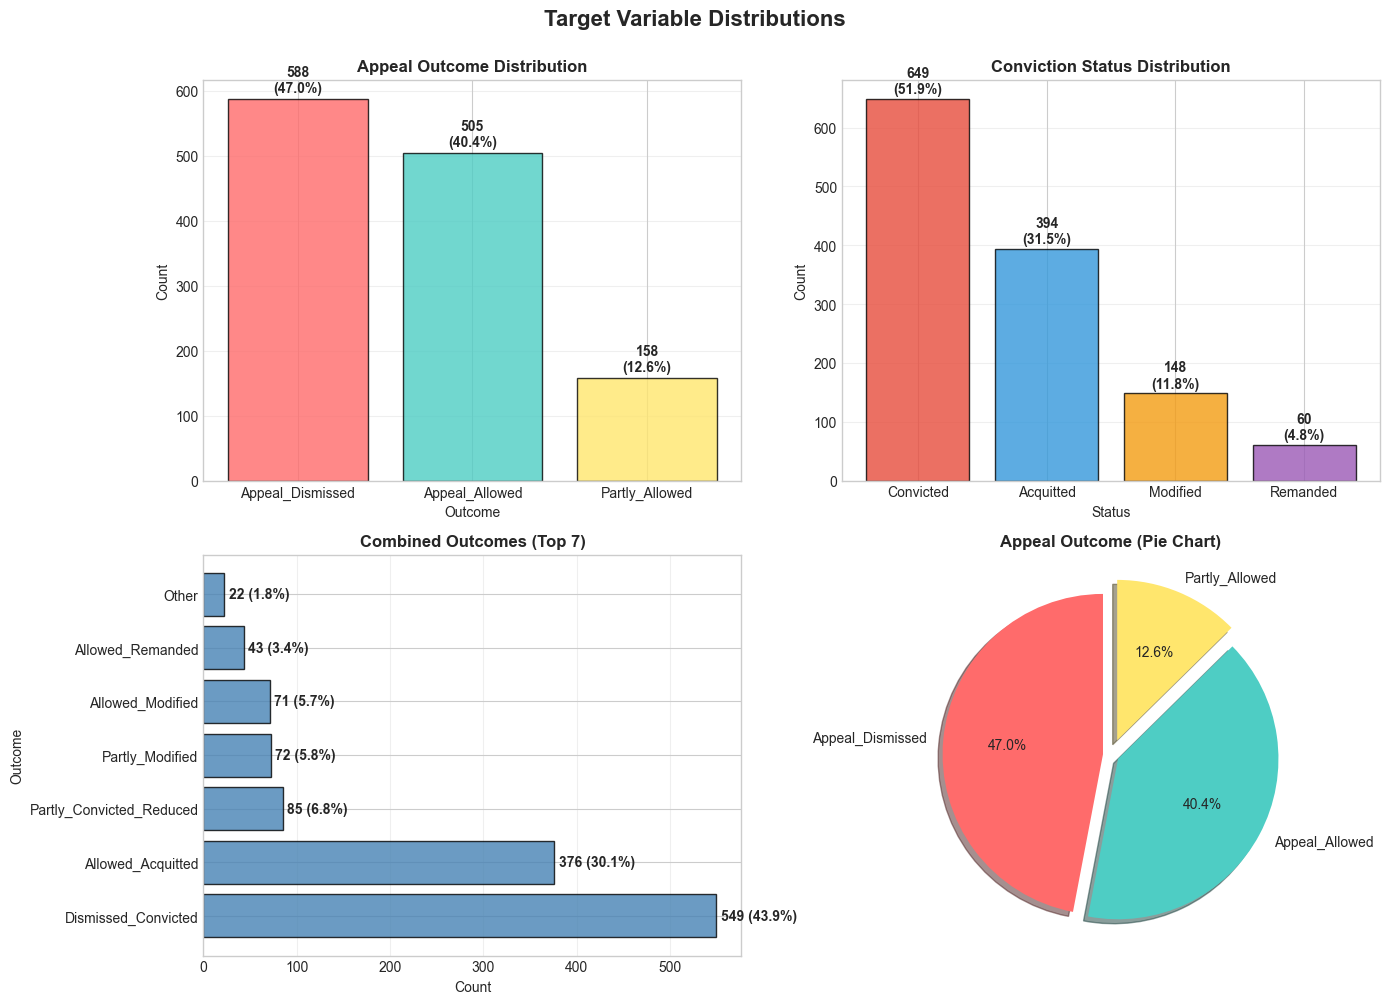

✅ Saved: viz_1_target_distributions.png

Creating Visualization 2: Offense Categories...


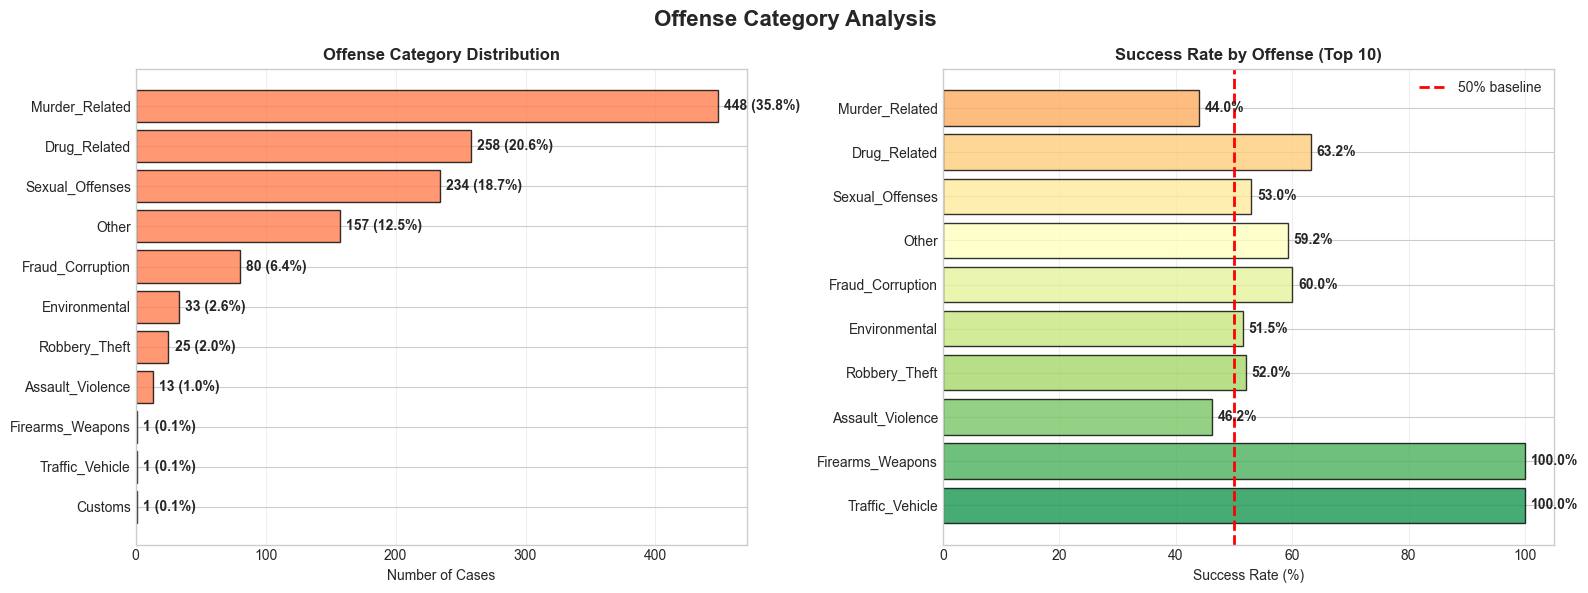

✅ Saved: viz_2_offense_analysis.png

Creating Visualization 3: Evidence Impact...


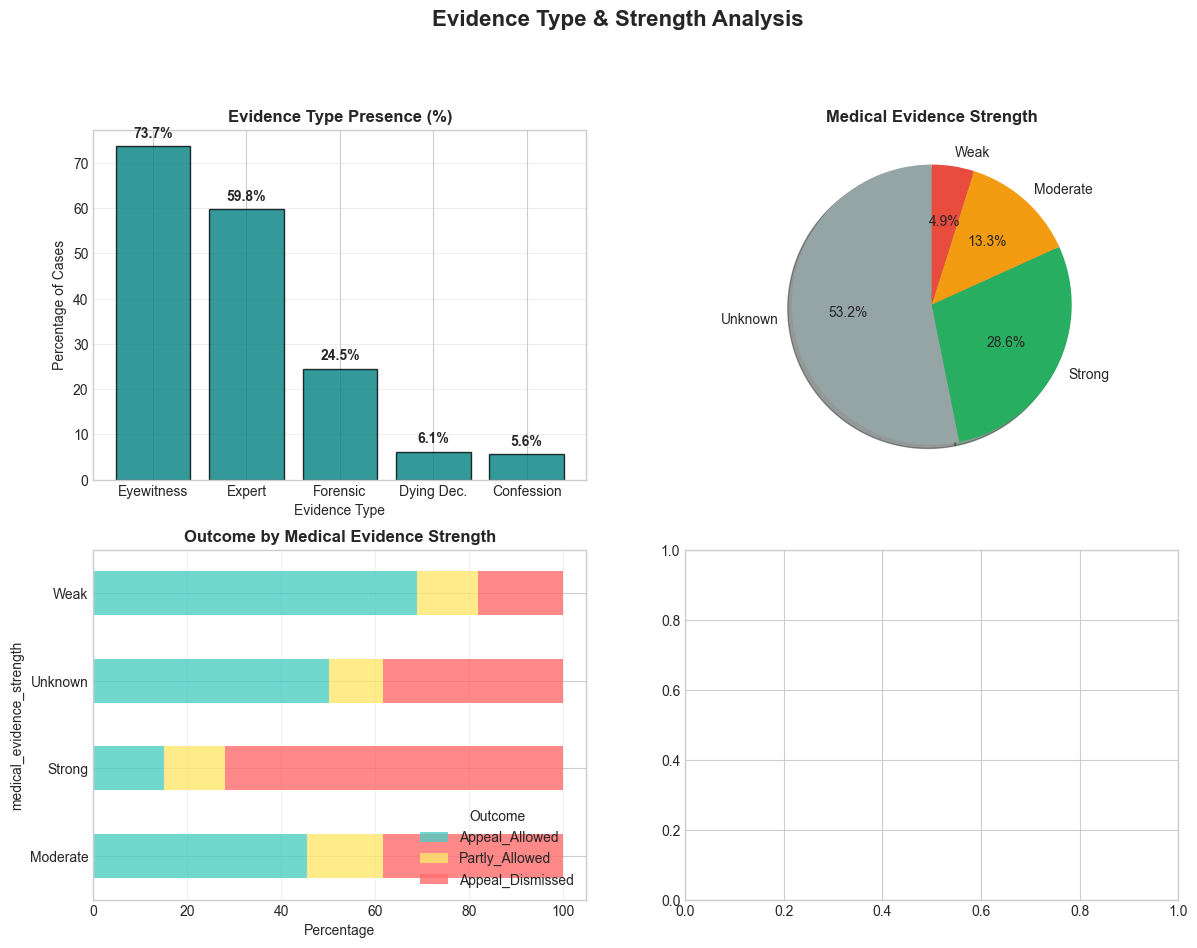

In [19]:
# ============================================
# EDA VISUALIZATIONS

# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("=" * 70)
print("EDA VISUALIZATIONS")
print("=" * 70)
print(f"Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print()

# Load cleaned dataset
df = pd.read_csv('dataset_cleaned_v2.csv')
print(f"✅ Loaded: {len(df)} records, {len(df.columns)} features")
print()

# ============================================
# VISUALIZATION 1: Target Variable Distribution
# ============================================
print("Creating Visualization 1: Target Variables...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Target Variable Distributions', fontsize=16, fontweight='bold', y=1.00)

# Plot 1: Appeal Outcome
outcome_counts = df['outcome_clean'].value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#FFE66D']
axes[0, 0].bar(outcome_counts.index, outcome_counts.values, color=colors, alpha=0.8, edgecolor='black')
axes[0, 0].set_title('Appeal Outcome Distribution', fontweight='bold')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_xlabel('Outcome')
for i, v in enumerate(outcome_counts.values):
    axes[0, 0].text(i, v + 10, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# Plot 2: Conviction Status
conviction_counts = df['conviction_clean'].value_counts()
colors2 = ['#E74C3C', '#3498DB', '#F39C12', '#9B59B6']
axes[0, 1].bar(conviction_counts.index, conviction_counts.values, color=colors2, alpha=0.8, edgecolor='black')
axes[0, 1].set_title('Conviction Status Distribution', fontweight='bold')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_xlabel('Status')
for i, v in enumerate(conviction_counts.values):
    axes[0, 1].text(i, v + 10, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

# Plot 3: Combined Outcome (Top 7)
combined_counts = df['combined_outcome'].value_counts().head(7)
axes[1, 0].barh(combined_counts.index, combined_counts.values, color='steelblue', alpha=0.8, edgecolor='black')
axes[1, 0].set_title('Combined Outcomes (Top 7)', fontweight='bold')
axes[1, 0].set_xlabel('Count')
axes[1, 0].set_ylabel('Outcome')
for i, v in enumerate(combined_counts.values):
    axes[1, 0].text(v + 5, i, f'{v} ({v/len(df)*100:.1f}%)', va='center', fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)

# Plot 4: Pie chart - Appeal Outcome
explode = (0.05, 0.05, 0.1)
axes[1, 1].pie(outcome_counts.values, labels=outcome_counts.index, autopct='%1.1f%%',
               colors=colors, explode=explode, shadow=True, startangle=90)
axes[1, 1].set_title('Appeal Outcome (Pie Chart)', fontweight='bold')

plt.tight_layout()
plt.savefig('viz_1_target_distributions.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: viz_1_target_distributions.png\n")

# ============================================
# VISUALIZATION 2: Offense Category Analysis
# ============================================
print("Creating Visualization 2: Offense Categories...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Offense Category Analysis', fontsize=16, fontweight='bold')

# Plot 1: Offense distribution
offense_counts = df['offence_category_grouped'].value_counts()
axes[0].barh(offense_counts.index, offense_counts.values, color='coral', alpha=0.8, edgecolor='black')
axes[0].set_title('Offense Category Distribution', fontweight='bold')
axes[0].set_xlabel('Number of Cases')
axes[0].invert_yaxis()
for i, v in enumerate(offense_counts.values):
    axes[0].text(v + 5, i, f'{v} ({v/len(df)*100:.1f}%)', va='center', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Plot 2: Success rate by offense
offense_success = []
for offense in offense_counts.head(10).index:
    offense_df = df[df['offence_category_grouped'] == offense]
    allowed = (offense_df['outcome_clean'] == 'Appeal_Allowed').sum()
    partly = (offense_df['outcome_clean'] == 'Partly_Allowed').sum()
    success_rate = (allowed + partly) / len(offense_df) * 100
    offense_success.append(success_rate)

offense_names = offense_counts.head(10).index
colors_gradient = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(offense_names)))
axes[1].barh(offense_names, offense_success, color=colors_gradient, alpha=0.8, edgecolor='black')
axes[1].set_title('Success Rate by Offense (Top 10)', fontweight='bold')
axes[1].set_xlabel('Success Rate (%)')
axes[1].invert_yaxis()
for i, v in enumerate(offense_success):
    axes[1].text(v + 1, i, f'{v:.1f}%', va='center', fontweight='bold')
axes[1].axvline(x=50, color='red', linestyle='--', linewidth=2, label='50% baseline')
axes[1].legend()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('viz_2_offense_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: viz_2_offense_analysis.png\n")

# ============================================
# VISUALIZATION 3: Evidence Analysis
# ============================================
print("Creating Visualization 3: Evidence Impact...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Evidence Type & Strength Analysis', fontsize=16, fontweight='bold', y=1.00)

# Plot 1: Evidence presence
evidence_fields = {
    'Eyewitness': 'eyewitness_present',
    'Expert': 'expert_evidence_present',
    'Forensic': 'forensic_evidence_present',
    'Dying Dec.': 'dying_declaration_present',
    'Confession': 'confession_present'
}

evidence_data = []
for name, field in evidence_fields.items():
    if field in df.columns:
        yes_count = (df[field] == 'Yes').sum()
        yes_pct = yes_count / len(df) * 100
        evidence_data.append({'Type': name, 'Present': yes_pct})

evidence_df = pd.DataFrame(evidence_data)
axes[0, 0].bar(evidence_df['Type'], evidence_df['Present'], color='teal', alpha=0.8, edgecolor='black')
axes[0, 0].set_title('Evidence Type Presence (%)', fontweight='bold')
axes[0, 0].set_ylabel('Percentage of Cases')
axes[0, 0].set_xlabel('Evidence Type')
for i, v in enumerate(evidence_df['Present']):
    axes[0, 0].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# Plot 2: Medical evidence strength
if 'medical_evidence_strength' in df.columns:
    med_counts = df['medical_evidence_strength'].value_counts()
    axes[0, 1].pie(med_counts.values, labels=med_counts.index, autopct='%1.1f%%',
                   colors=['#95A5A6', '#27AE60', '#F39C12', '#E74C3C'], 
                   startangle=90, shadow=True)
    axes[0, 1].set_title('Medical Evidence Strength', fontweight='bold')

# Plot 3: Success rate by medical evidence
med_outcome = pd.crosstab(df['medical_evidence_strength'], df['outcome_clean'], normalize='index') * 100
med_outcome = med_outcome[['Appeal_Allowed', 'Partly_Allowed', 'Appeal_Dismissed']]
med_outcome.plot(kind='barh', stacked=True, ax=axes[1, 0], 
                 color=['#4ECDC4', '#FFE66D', '#FF6B6B'], alpha=0.8)
axes[1, 0].set_title('Outcome by Medical Evidence Strength', fontweight='bold')
axes[1, 0].set_xlabel('Percentage')
axes[1, 0].legend(title='Outcome', loc='lower right')
axes[1, 0].grid(axis='x', alpha=0.3)

# Plot 4: Chain of custody quality
if 'chain_of_custody_quality' in df.columns:
    custody_counts = df['chain_of_custody_quality'].value_counts()
    axes[1, 1]
